In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [4]:
import os 

os.chdir("..")
print(os.getcwd())

e:\project_archive\new project


In [5]:
from pathlib import Path 

data_path = Path("data/raw")

if not data_path.exists():
    raise FileNotFoundError

In [6]:
student_data_path = data_path / "student_academic_data" / "data.csv"

if not student_data_path.exists():
    raise FileNotFoundError

In [8]:
df = pd.read_csv(student_data_path, sep=";")

In [9]:
# Clean up column names (strip whitespace/tabs)
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)

# Define target variable
target_col = "Target"

In [35]:
# Automatically identify numerical and categorical/discrete columns
# Based on unique value thresholds
unique_counts = df.drop(columns=[target_col]).nunique()
categorical_cols = unique_counts[unique_counts <= 10].index.tolist()
numerical_cols = unique_counts[unique_counts > 10].index.tolist()


In [36]:
print(f"Datset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical/Discreate feature ({len(categorical_cols)}): {categorical_cols}")

Datset Loaded: 4424 rows, 37 columns
Numerical features (22): ['Application mode', 'Course', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']
Categorical/Discreate feature (14): ['Marital status', 'Application order', 'Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 2n

# 1. Dataset Overview

In [16]:
print("----Head---")
display(df.head())

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIPTIVE STATISTICS ---")
display(df.describe().T)

----Head---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [18]:
print("--- MISSING VALUES ---")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.")

--- MISSING VALUES ---
No missing values found.


In [19]:
print("\n--- DUPLICATE ROWS ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


--- DUPLICATE ROWS ---
Number of duplicate rows: 0


In [20]:
print("\n--- DATA TYPES CHECK ---")
print(df.dtypes)


--- DATA TYPES CHECK ---
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                       

3. Target Variable Analysis

In [21]:
import re

def safe_filename(name: str) -> str:
    name = name.strip()          # Removes leading/trailing whitespace and tabs
    name = name.lower()
    name = re.sub(r'[<>:"/\\|?*]+', "_", name)  # Replace invalid filename characters
    name = re.sub(r"\s+", "_", name)            # Replace spaces with underscores
    return name

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt

figures_paths = Path("artifacts/reports/figures")
figures_paths.mkdir(exist_ok=True)

def save_plot(filename: str, subfolder: str | None = None):
    if subfolder is None:
        save_dir = figures_paths
    else:
        save_dir = figures_paths / subfolder
 
    save_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")

filename = f"{safe_filename("target_variable_distribustion")}.png"

save_plot(filename=filename)

In [31]:
print("Target Class Percentages:")
print(df[target_col].value_counts(normalize=True) * 100)

Target Class Percentages:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


4. Univariate Analysis

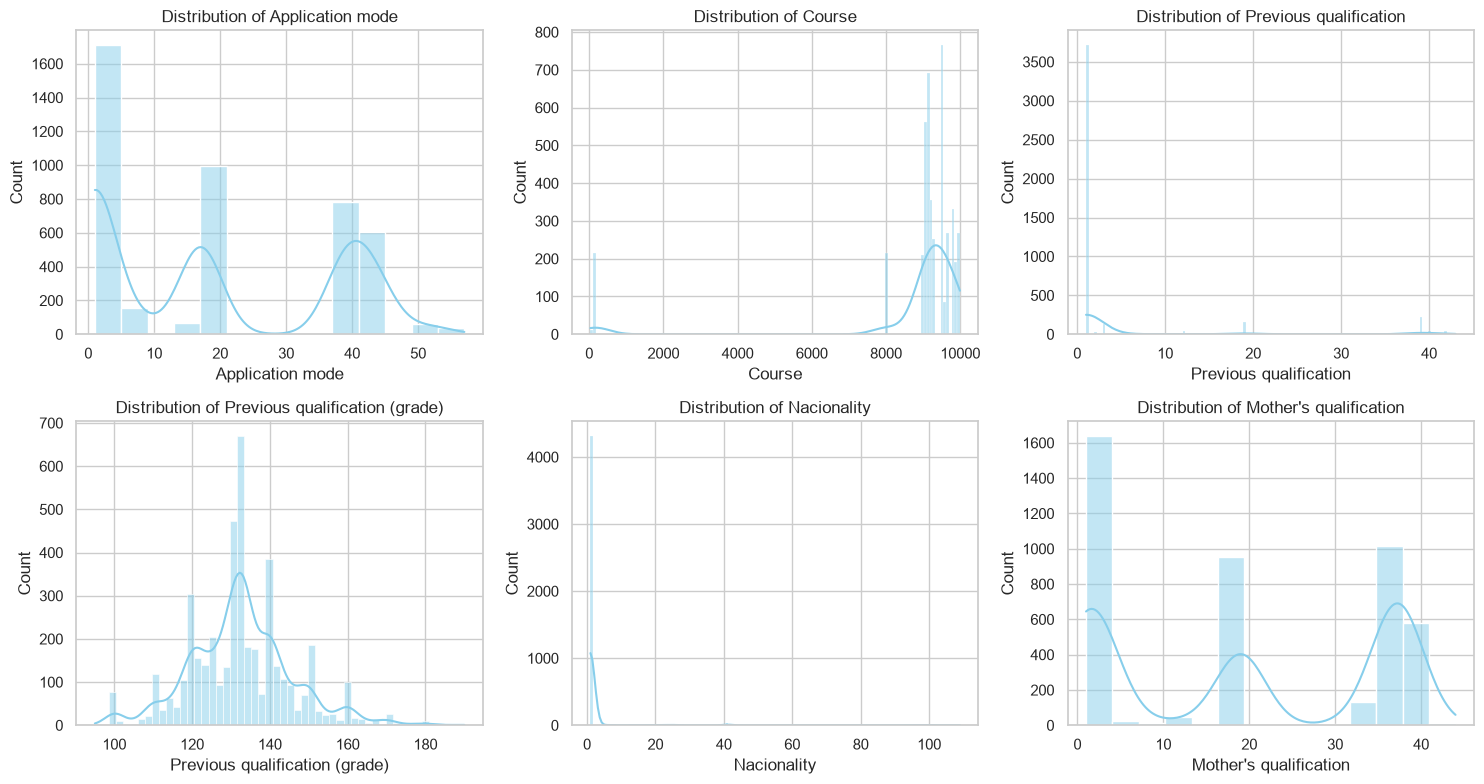

In [38]:
# Plot distributions of key numerical variables
num_to_plot = numerical_cols[:6]  # Limit plots to prevent overcrowding
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

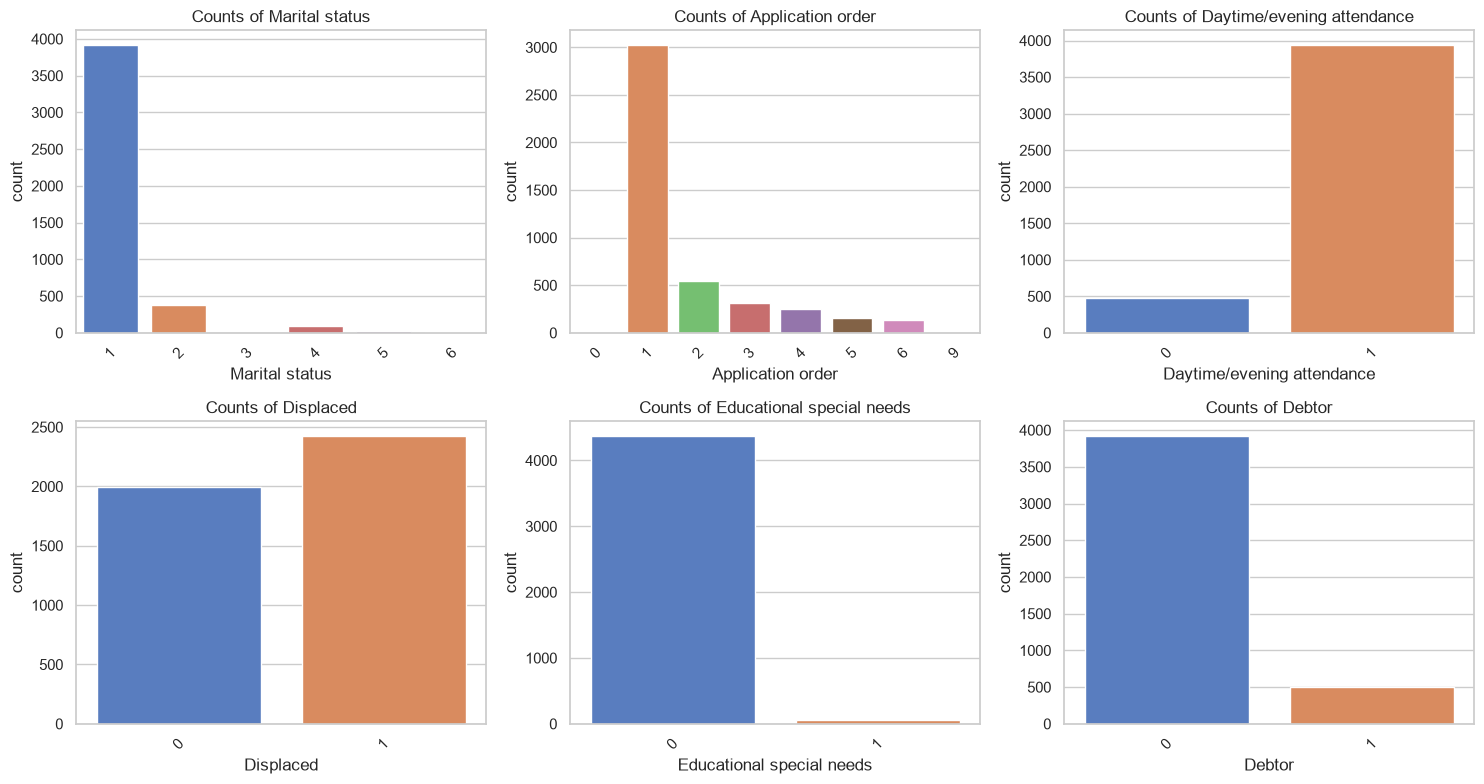

In [39]:
# Plot distributions of key categorical variables
cat_to_plot = categorical_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette="muted")
    axes[i].set_title(f"Counts of {col}")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

5. Bivariate Analysis

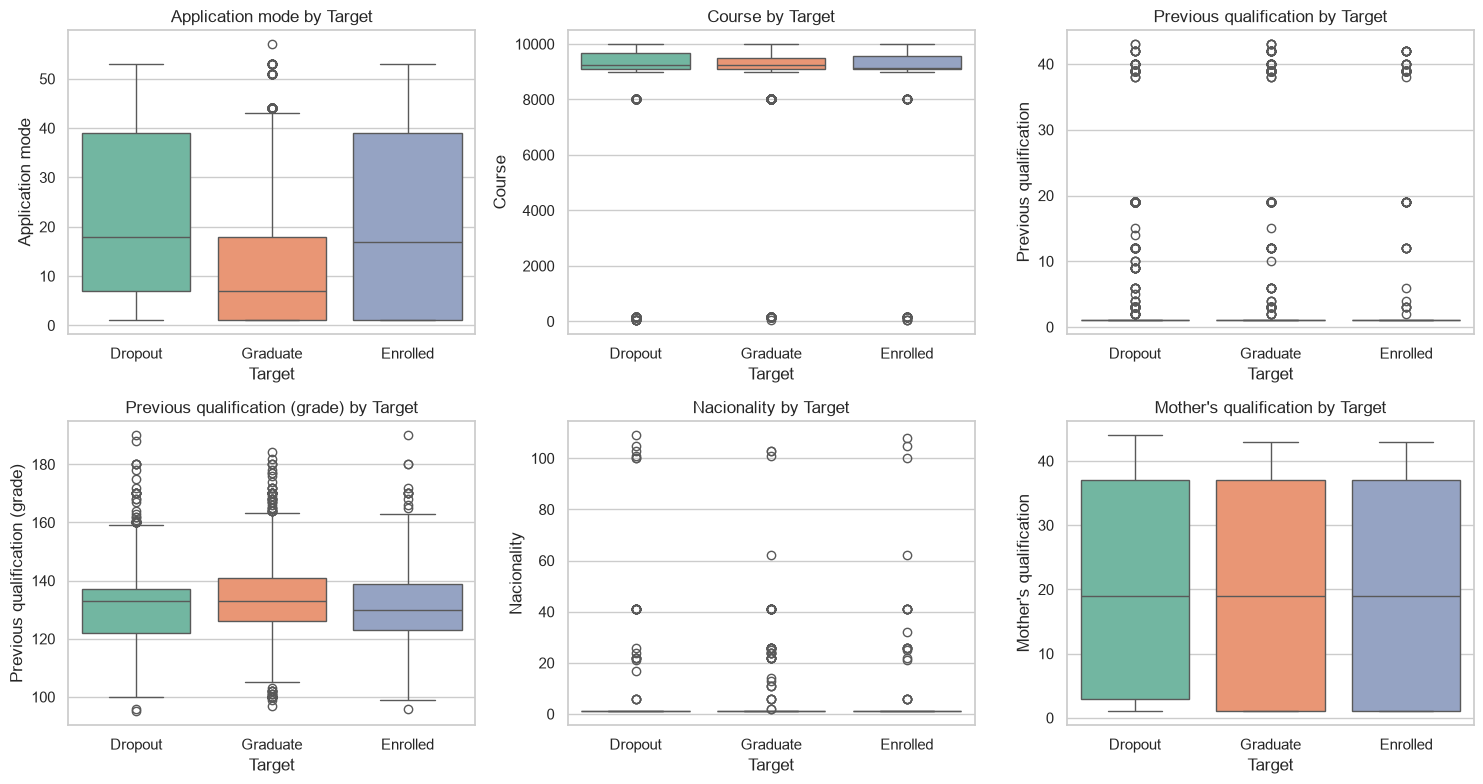

In [40]:
# 5.1 Numerical vs Target

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_to_plot):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by Target")
plt.tight_layout()
plt.show()

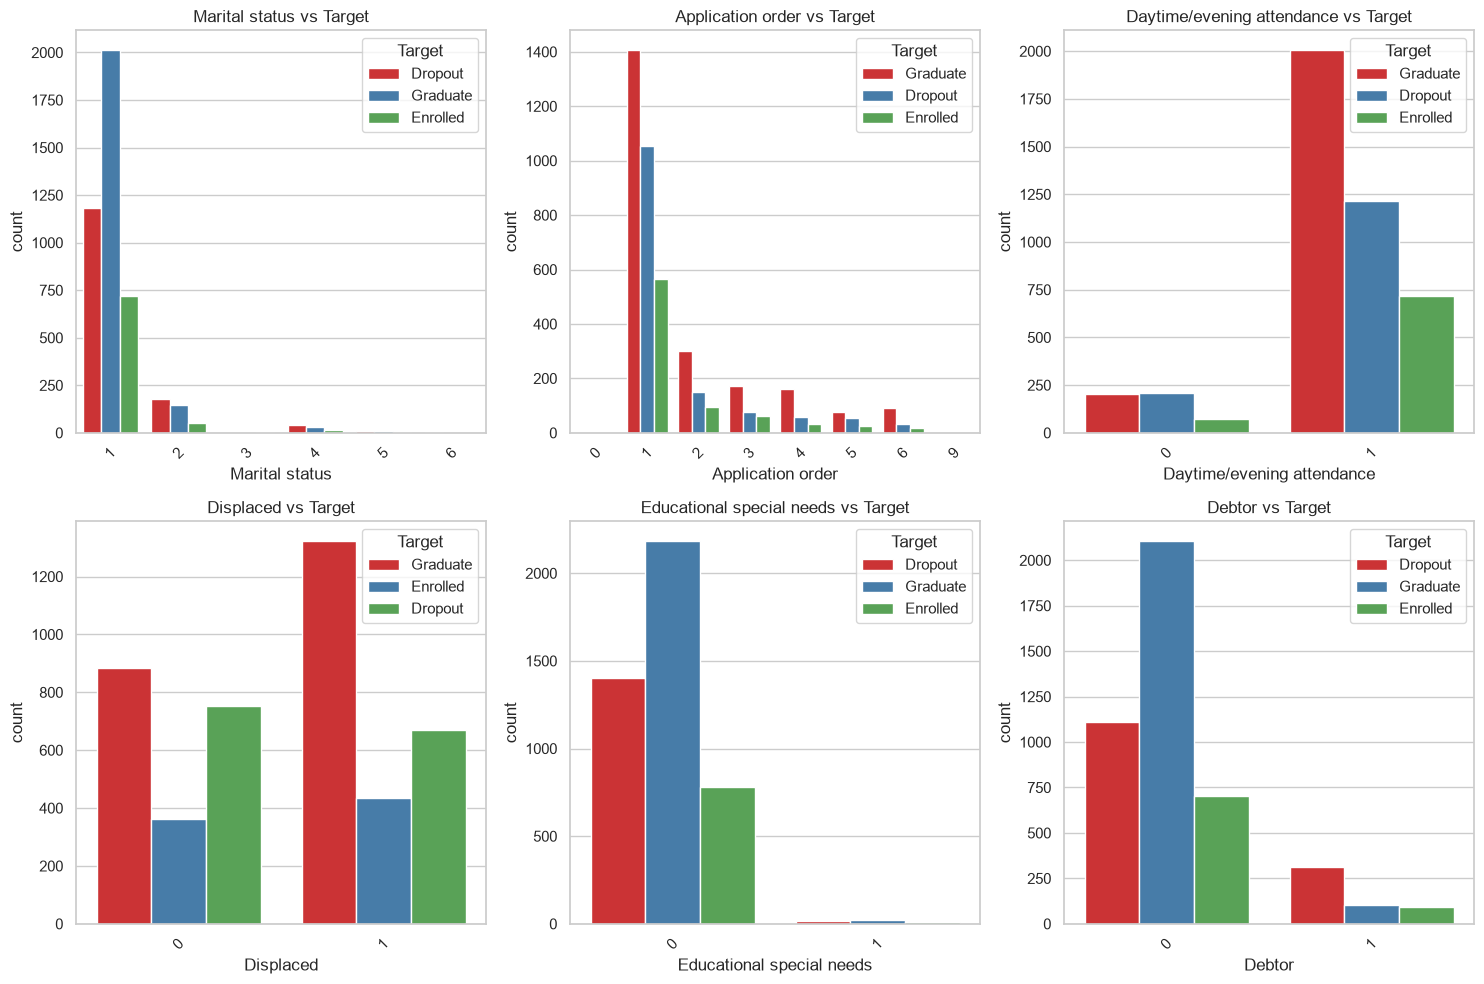

In [41]:
# 5.2 Categorical vs Target

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(cat_to_plot):
    sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette="Set1")
    axes[i].set_title(f"{col} vs Target")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

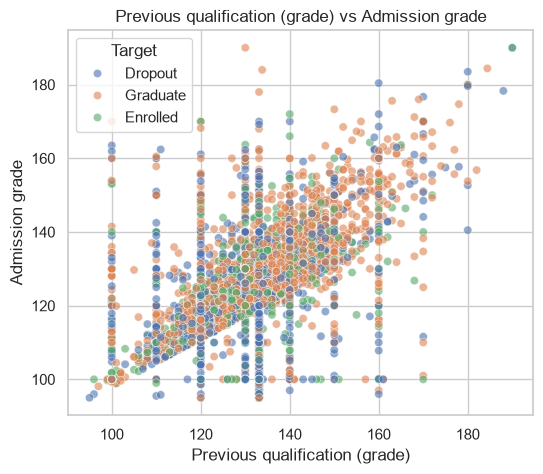

In [42]:
# 5.3 Numerical vs Numerical
# Correlation scatter plot of two related numerical features (e.g., Grades across semesters)

grade_cols = [c for c in numerical_cols if "grade" in c.lower()][:2]
if len(grade_cols) >= 2:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x=grade_cols[0], y=grade_cols[1], hue=target_col, alpha=0.6)
    plt.title(f"{grade_cols[0]} vs {grade_cols[1]}")
    plt.show()

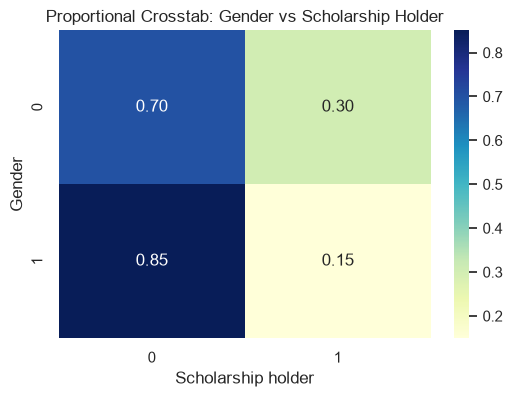

In [43]:
# 5.4 Categorical vs Categorical
# Cross-tabulation of two categorical variables (e.g., Gender vs Scholarship holder)

if "Gender" in df.columns and "Scholarship holder" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.crosstab(df["Gender"], df["Scholarship holder"], normalize="index"), annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Proportional Crosstab: Gender vs Scholarship Holder")
    plt.show()

6. Correlation Analysis

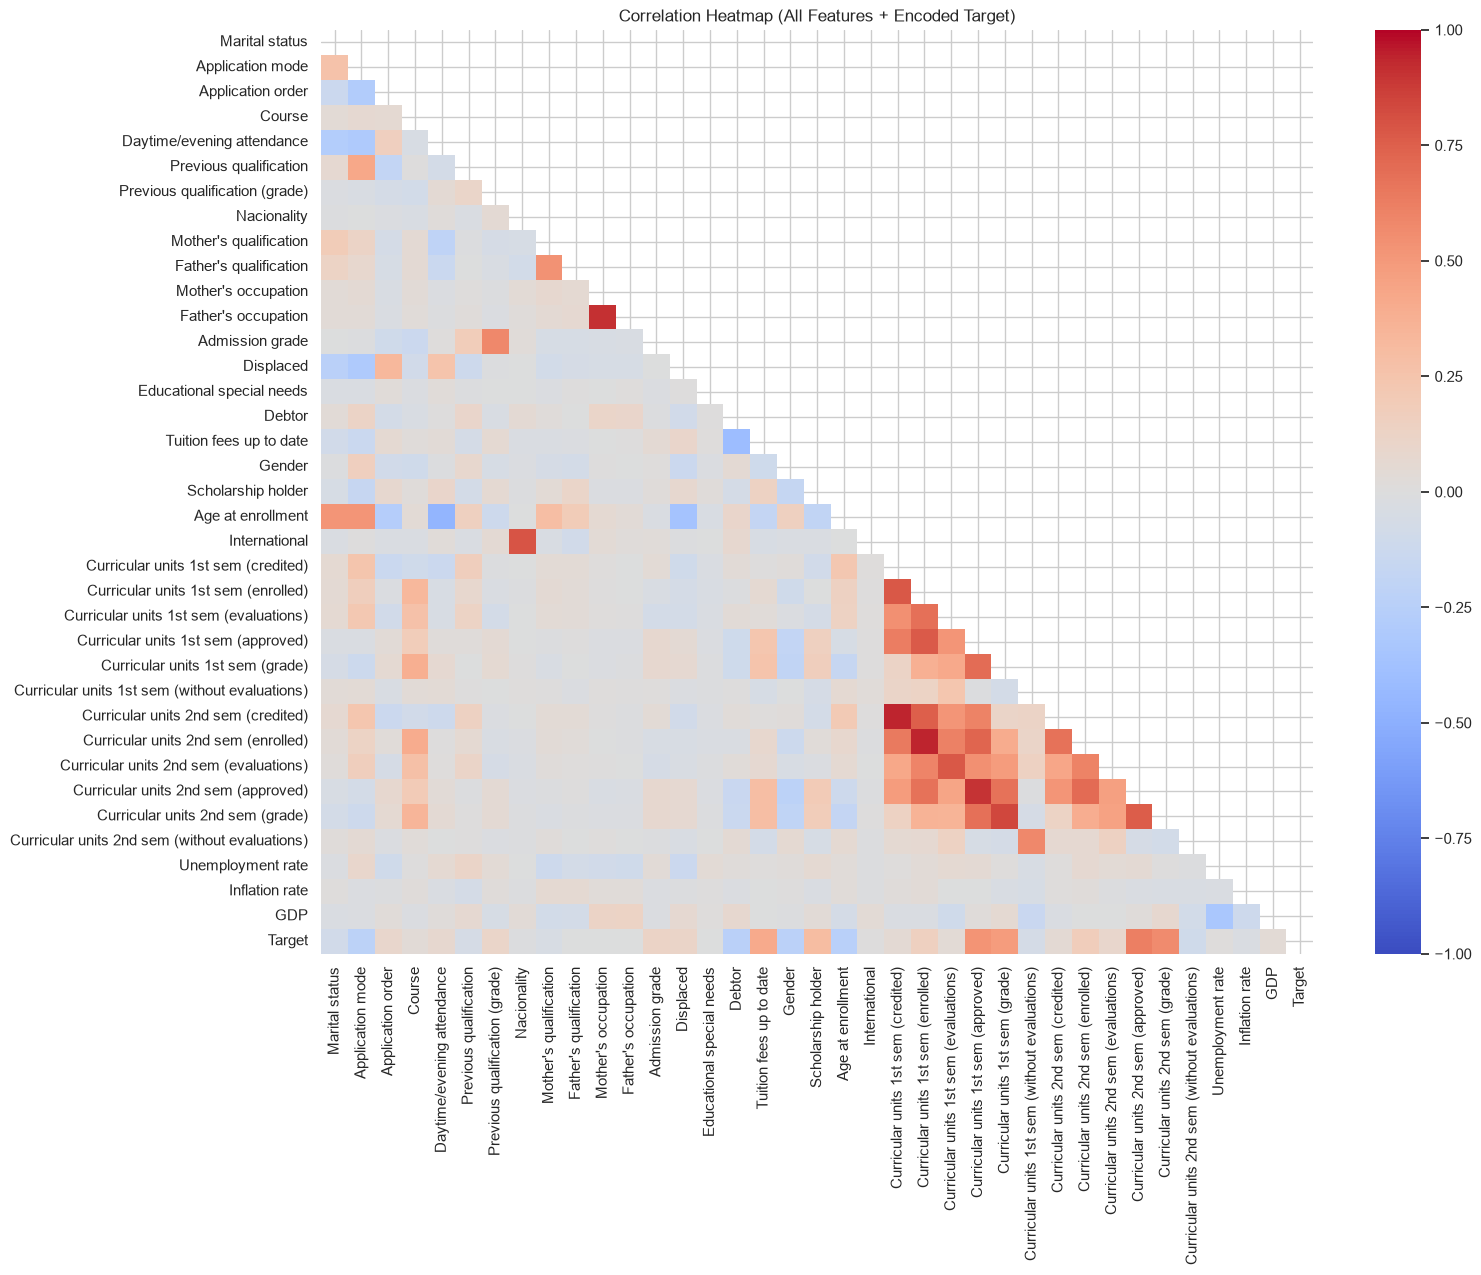

In [44]:
from sklearn.preprocessing import LabelEncoder

# Encode target numerically for correlation analysis map
df_encoded = df.copy()
df_encoded[target_col] = LabelEncoder().fit_transform(df_encoded[target_col])

plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, annot=False, fmt=".2f")
plt.title("Correlation Heatmap (All Features + Encoded Target)")
plt.show()

7. Multicollinearity Analysis (VIF)

In [56]:
# Drop target for VIF check, and drop non-numeric structural values if any exist
X_vif = df_encoded.drop(columns=[target_col]).select_dtypes(include=[np.number])

# Add a constant flag for VIF calculation stability
X_vif["intercept"] = 1

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["feature"] != "intercept"].sort_values(by="VIF", ascending=False)

print("Features with potential multicollinearity issues (VIF > 5):")
display(vif_data[vif_data["VIF"] > 5])

Features with potential multicollinearity issues (VIF > 5):


,feature,VIF
22,Curricular units 1st sem (enrolled),24.482511
28,Curricular units 2nd sem (enrolled),17.207212
21,Curricular units 1st sem (credited),16.223547
24,Curricular units 1st sem (approved),13.103872
27,Curricular units 2nd sem (credited),12.591785
30,Curricular units 2nd sem (approved),10.736544
10,Mother's occupation,5.979421
11,Father's occupation,5.970843
31,Curricular units 2nd sem (grade),5.778227
25,Curricular units 1st sem (grade),5.197275


8. Statistical Analysis

In [47]:
print("--- ANOVA / Kruskal-Wallis Test for Numerical Features across Target Classes ---")
stat_results = []
for col in numerical_cols:
    groups = [group[1].values for group in df[col].groupby(df[target_col])]
    # Using Kruskal because academic grades/rates are rarely strictly normal
    stat, p_val = stats.kruskal(*groups)
    stat_results.append({"Feature": col, "Kruskal_Stat": stat, "p_value": p_val})

stat_df = pd.DataFrame(stat_results).sort_values(by="p_value")
display(stat_df.head(10))

--- ANOVA / Kruskal-Wallis Test for Numerical Features across Target Classes ---


,Feature,Kruskal_Stat,p_value
14,Curricular units 1st sem (approved),1561.739455,0.000000e+00
20,Curricular units 2nd sem (approved),1892.276492,0.000000e+00
21,Curricular units 2nd sem (grade),1390.731330,1.015147e-302
15,Curricular units 1st sem (grade),1094.186486,2.514338e-238
10,Age at enrollment,375.106923,3.520194e-82
18,Curricular units 2nd sem (enrolled),270.731504,1.627050e-59
12,Curricular units 1st sem (enrolled),246.617133,2.803949e-54
0,Application mode,202.785714,9.239354e-45
19,Curricular units 2nd sem (evaluations),182.946432,1.877963e-40
13,Curricular units 1st sem (evaluations),130.658781,4.244301e-29


9. Outlier Analysis

In [48]:
# Identify extreme outliers using IQR method for numerical features
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = [outliers, round((outliers / len(df)) * 100, 2)]

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count", "Percentage (%)"])
print("Outlier Assessment Matrix:")
display(outlier_df.sort_values(by="Outlier Count", ascending=False))

Outlier Assessment Matrix:


,Outlier Count,Percentage (%)
Curricular units 2nd sem (grade),877,19.82
Curricular units 1st sem (grade),726,16.41
Previous qualification,707,15.98
Curricular units 1st sem (credited),577,13.04
Curricular units 2nd sem (credited),530,11.98
Course,442,9.99
Age at enrollment,441,9.97
Curricular units 1st sem (enrolled),424,9.58
Curricular units 2nd sem (enrolled),369,8.34
Curricular units 1st sem (without evaluations),294,6.65


10. Feature Importance Analysis

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

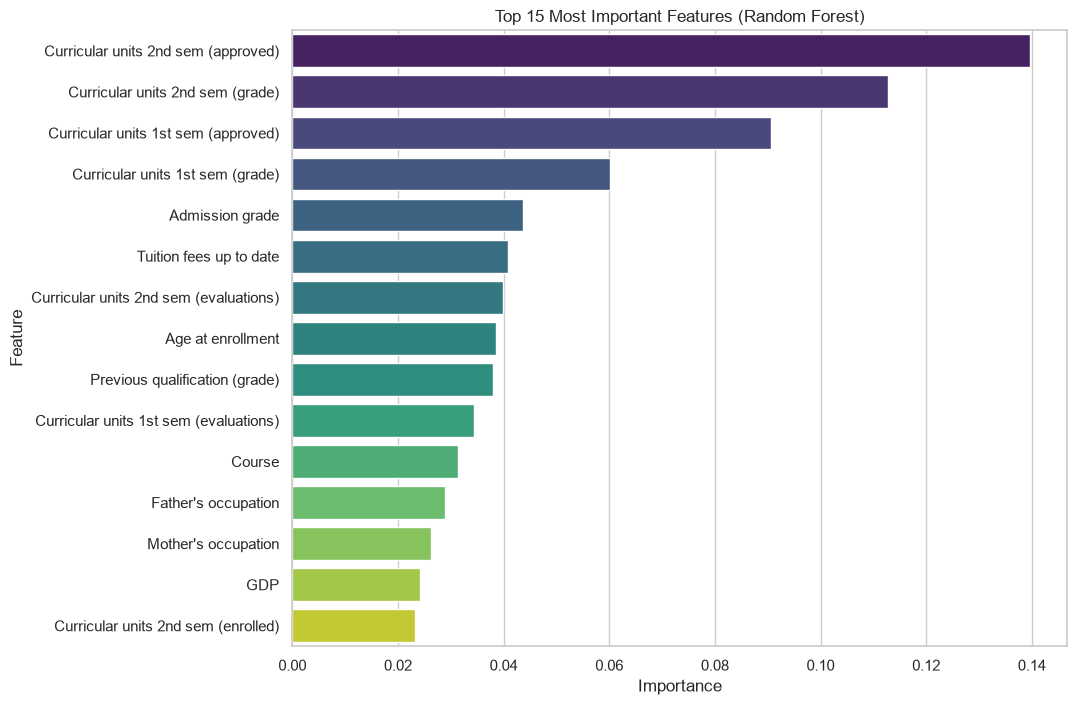

In [51]:
# Prep Features for Quick Tree Ensemble Evaluation
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y)

importances = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.show()

11. Feature Distribution Analysis (Skewness & Kurtosis)

In [52]:
dist_metrics = []
for col in numerical_cols:
    dist_metrics.append({"Feature": col, "Skewness": df[col].skew(), "Kurtosis": df[col].kurt()})

dist_df = pd.DataFrame(dist_metrics)
print("Distribution Shape Evaluation:")
display(dist_df)

Distribution Shape Evaluation:


,Feature,Skewness,Kurtosis
0,Application mode,0.393036,-1.453806
1,Course,-3.809135,13.199149
2,Previous qualification,2.871207,6.778166
3,Previous qualification (grade),0.312867,0.968258
4,Nacionality,10.703998,135.146206
5,Mother's qualification,0.001978,-1.692292
6,Father's qualification,-0.298697,-1.580592
7,Mother's occupation,5.339227,29.226145
8,Father's occupation,5.395173,29.927395
9,Admission grade,0.530600,0.662725


12. Cardinality Analysis

In [53]:
cardinality = df[categorical_cols].nunique().sort_values(ascending=False).to_frame(name="Unique Values")
print("Cardinality of Categorical Features:")
display(cardinality)

Cardinality of Categorical Features:


,Unique Values
GDP,10
Unemployment rate,10
Curricular units 2nd sem (without evaluations),10
Inflation rate,9
Application order,8
Marital status,6
Debtor,2
Educational special needs,2
Displaced,2
Daytime/evening attendance,2


13. Data Leakage Analysis

In [54]:
# Look for features perfectly predicting target or evaluation items tracking post-outcome metrics
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"Feature": X.columns, "Mutual Information": mi_scores}).sort_values(by="Mutual Information", ascending=False)

print("Mutual Information Scores (Check for suspiciously high scores near 1.0):")
display(mi_df.head(10))

Mutual Information Scores (Check for suspiciously high scores near 1.0):


,Feature,Mutual Information
30,Curricular units 2nd sem (approved),0.310207
31,Curricular units 2nd sem (grade),0.239324
24,Curricular units 1st sem (approved),0.233439
25,Curricular units 1st sem (grade),0.184882
16,Tuition fees up to date,0.100460
29,Curricular units 2nd sem (evaluations),0.096761
23,Curricular units 1st sem (evaluations),0.075691
19,Age at enrollment,0.065516
3,Course,0.053425
22,Curricular units 1st sem (enrolled),0.052744


14. Feature Selection Analysis

In [57]:
# Combining VIF, High Correlation, and Mutual Information to select strong predictive subsets
high_vif_features = vif_data[vif_data["VIF"] > 10]["feature"].tolist()
low_mi_features = mi_df[mi_df["Mutual Information"] < 0.01]["Feature"].tolist()

# Propose dropping redundant paired multi-collinear units (e.g., prioritizing 2nd sem over 1st sem if identical)
features_to_drop = list(set(low_mi_features + [f for f in high_vif_features if "1st sem" in f]))
selected_features = [col for col in X.columns if col not in features_to_drop]

print(f"Suggested Dropped Features ({len(features_to_drop)}): {features_to_drop}")
print(f"\nFinal Selected Feature Set Size: {len(selected_features)}")

Suggested Dropped Features (13): ['International', 'Nacionality', 'Unemployment rate', 'Educational special needs', 'Displaced', 'Curricular units 1st sem (without evaluations)', 'Curricular units 1st sem (credited)', 'Daytime/evening attendance', 'Curricular units 2nd sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 1st sem (enrolled)', 'GDP', 'Curricular units 1st sem (approved)']

Final Selected Feature Set Size: 23


In [43]:

for col in cat_cols:
  print(f"\n{'='*50}")
  print(col)
  plt.figure(figsize=(7, 5))

  sns.boxplot(
    x="Target",
    y="Previous qualification (grade)",
    data=df
  )
  
  plt.title(f"{col} vs target")
  plt.xlabel("Target")
  plt.ylabel(col)

  filename = f"{safe_filename(col)}_boxplot.png"
  save_plot(filename=filename, subfolder="categorical_vs_target_boxplot")




Marital status

Application mode

Application order

Course

Daytime/evening attendance	


C:\Users\Asus\AppData\Local\Temp\ipykernel_372\3945167156.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(



Previous qualification

Nacionality

Mother's qualification

Father's qualification

Mother's occupation

Father's occupation

Displaced

Educational special needs

Debtor

Tuition fees up to date

Gender

Scholarship holder

International
